## 需要老师check

Selected samples count: 2000


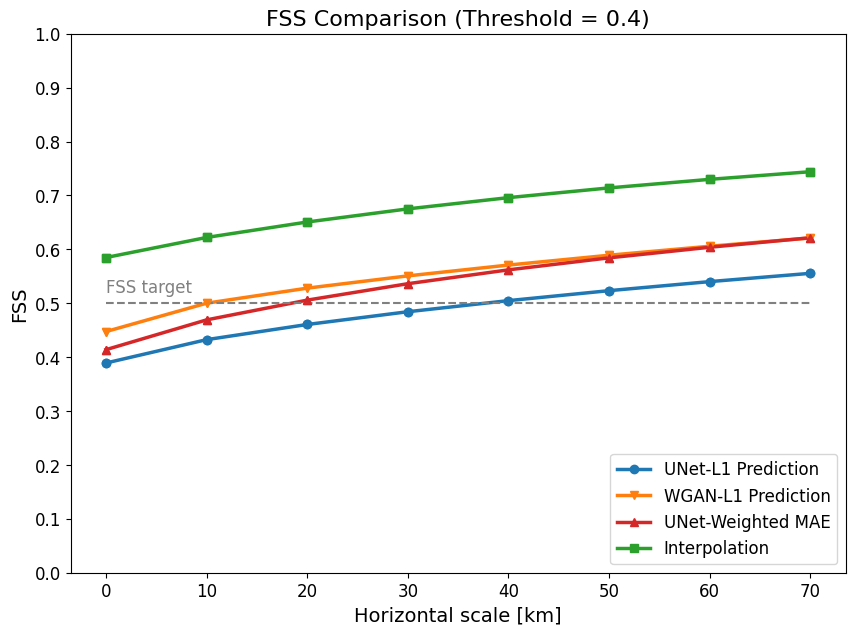

In [4]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import random
from pysteps.verification.spatialscores import fss

# 文件路径
unet_path = "/cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/public/ShiXiSheng/yzy/yzy_results/ex7_13_onestep_l1_nofc_aheadtop_10_addprecipnorm/prcp_downs_unet_year_2020.nc"
wgan_path = "/cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/public/ShiXiSheng/yzy/yzy_results/ex31_7_onestepwgan_cri5_1000_0_l1_aheadtop_10_180epoch_addprecipnorm/prcp_downs_wgan_year_2020.nc"
unet_wmae_path = "/cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/public/ShiXiSheng/yzy/yzy_results/ex14_2_onestep_weightmae_aheadtop_10_addprecipnorm_1_6_30_80/prcp_downs_unet_year_2020.nc"

threshold = 0.4
scales = list(range(0, 80, 10))  # 空间尺度
num_samples = 2000  # 采样数量

# 加载数据集
ds_unet = xr.open_dataset(unet_path)
fcst_unet = ds_unet['fcst'].values
inter = ds_unet['inter'].values
hr = ds_unet['hr'].values

ds_wgan = xr.open_dataset(wgan_path)
fcst_wgan = ds_wgan['fcst'].values

ds_unet_wmae = xr.open_dataset(unet_wmae_path)
fcst_unet_wmae = ds_unet_wmae['fcst'].values

# 筛选强降水事件样本
samples = [s for s in range(fcst_unet.shape[0]) if np.sum(hr[s] > 5) > 10]
samples = random.sample(samples, min(num_samples, len(samples)))
print(f"Selected samples count: {len(samples)}")

# 初始化存储 FSS 的列表
fss_mean_unet = []
fss_mean_wgan = []
fss_mean_inter = []
fss_mean_unet_wmae = []

fss_std_unet = []
fss_std_wgan = []
fss_std_inter = []
fss_std_unet_wmae = []

# 遍历不同空间尺度，计算 FSS
for scale in scales:
    fss_values_unet = []
    fss_values_wgan = []
    fss_values_inter = []
    fss_values_unet_wmae = []

    for s in samples:
        try:
            # 计算 FSS
            fss_unet = fss(fcst_unet[s], hr[s], threshold, scale)
            fss_wgan = fss(fcst_wgan[s], hr[s], threshold, scale)
            fss_unet_wmae = fss(fcst_unet_wmae[s], hr[s], threshold, scale)
            fss_int = fss(inter[s], hr[s], threshold, scale)

            # 存储结果
            fss_values_unet.append(fss_unet)
            fss_values_wgan.append(fss_wgan)
            fss_values_unet_wmae.append(fss_unet_wmae)
            fss_values_inter.append(fss_int)

        except ValueError:
            continue

    # 计算均值和标准差
    fss_mean_unet.append(np.nanmean(fss_values_unet))
    fss_mean_wgan.append(np.nanmean(fss_values_wgan))
    fss_mean_unet_wmae.append(np.nanmean(fss_values_unet_wmae))
    fss_mean_inter.append(np.nanmean(fss_values_inter))
    
    fss_std_unet.append(np.nanstd(fss_values_unet))
    fss_std_wgan.append(np.nanstd(fss_values_wgan))
    fss_std_unet_wmae.append(np.nanstd(fss_values_unet_wmae))
    fss_std_inter.append(np.nanstd(fss_values_inter))

# 绘图
plt.figure(figsize=(10, 7))

# UNet-L1 折线和标记
plt.plot(scales, fss_mean_unet, '-o', label='UNet-L1 Prediction', linewidth=2.5, color='tab:blue')
plt.errorbar(scales, fss_mean_unet, yerr=fss_std_unet, elinewidth=0, fmt='o', capsize=0, color='tab:blue', alpha=0.9)

# WGAN-L1 折线和标记
plt.plot(scales, fss_mean_wgan, '-v', label='WGAN-L1 Prediction', linewidth=2.5, color='tab:orange')
plt.errorbar(scales, fss_mean_wgan, yerr=fss_std_wgan, elinewidth=0, fmt='v', capsize=0, color='tab:orange', alpha=0.9)

# UNet-Weighted MAE 折线和标记
plt.plot(scales, fss_mean_unet_wmae, '-^', label='UNet-Weighted MAE', linewidth=2.5, color='tab:red')
plt.errorbar(scales, fss_mean_unet_wmae, yerr=fss_std_unet_wmae, elinewidth=0, fmt='^', capsize=0, color='tab:red', alpha=0.9)

# 插值结果 折线和标记
plt.plot(scales, fss_mean_inter, '-s', label='Interpolation', linewidth=2.5, color='tab:green')
plt.errorbar(scales, fss_mean_inter, yerr=fss_std_inter, elinewidth=0, fmt='s', capsize=0, color='tab:green', alpha=0.9)

# 添加 y=0.5 的虚线，只在x轴刻度范围内绘制
plt.plot([scales[0], scales[-1]], [0.5, 0.5], color='gray', linestyle='--', linewidth=1.5)
plt.text(scales[0], 0.52, 'FSS target', fontsize=12, color='gray')

plt.xlabel('Horizontal scale [km]', fontsize=14)
plt.ylabel('FSS', fontsize=14)
plt.title(f'FSS Comparison (Threshold = {threshold})', fontsize=16)
plt.ylim(0, 1.0)
plt.xticks(scales, fontsize=12)
plt.yticks(np.arange(0, 1.1, 0.1), fontsize=12)

plt.legend(fontsize=12, loc='lower right')
plt.grid(False)
plt.show()


Selected samples count: 2000


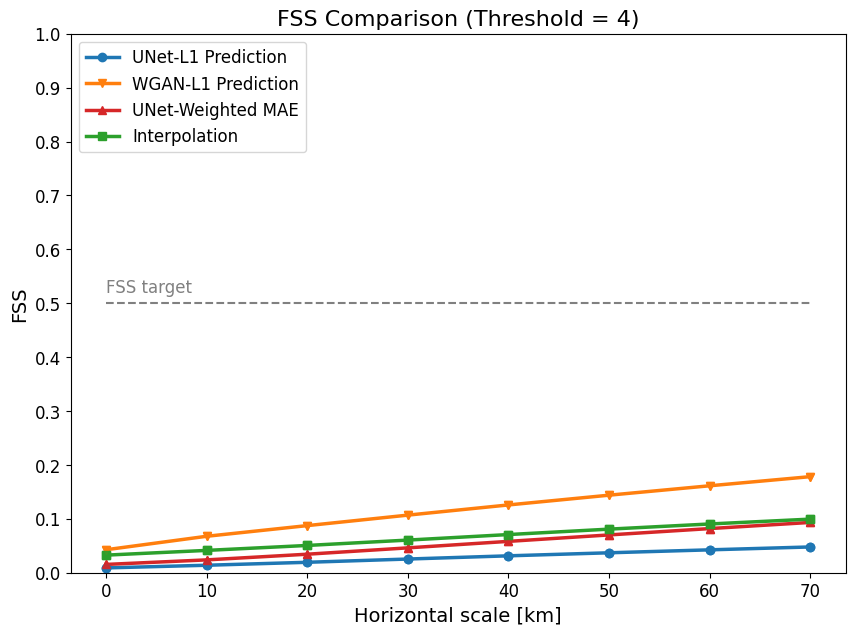

In [5]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import random
from pysteps.verification.spatialscores import fss

# 文件路径
unet_path = "/cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/public/ShiXiSheng/yzy/yzy_results/ex7_13_onestep_l1_nofc_aheadtop_10_addprecipnorm/prcp_downs_unet_year_2020.nc"
wgan_path = "/cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/public/ShiXiSheng/yzy/yzy_results/ex31_7_onestepwgan_cri5_1000_0_l1_aheadtop_10_180epoch_addprecipnorm/prcp_downs_wgan_year_2020.nc"
unet_wmae_path = "/cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/public/ShiXiSheng/yzy/yzy_results/ex14_2_onestep_weightmae_aheadtop_10_addprecipnorm_1_6_30_80/prcp_downs_unet_year_2020.nc"

threshold = 4
scales = list(range(0, 80, 10))  # 空间尺度
num_samples = 2000  # 采样数量

# 加载数据集
ds_unet = xr.open_dataset(unet_path)
fcst_unet = ds_unet['fcst'].values
inter = ds_unet['inter'].values
hr = ds_unet['hr'].values

ds_wgan = xr.open_dataset(wgan_path)
fcst_wgan = ds_wgan['fcst'].values

ds_unet_wmae = xr.open_dataset(unet_wmae_path)
fcst_unet_wmae = ds_unet_wmae['fcst'].values

# 筛选强降水事件样本
samples = [s for s in range(fcst_unet.shape[0]) if np.sum(hr[s] > 5) > 10]
samples = random.sample(samples, min(num_samples, len(samples)))
print(f"Selected samples count: {len(samples)}")

# 初始化存储 FSS 的列表
fss_mean_unet = []
fss_mean_wgan = []
fss_mean_inter = []
fss_mean_unet_wmae = []

fss_std_unet = []
fss_std_wgan = []
fss_std_inter = []
fss_std_unet_wmae = []

# 遍历不同空间尺度，计算 FSS
for scale in scales:
    fss_values_unet = []
    fss_values_wgan = []
    fss_values_inter = []
    fss_values_unet_wmae = []

    for s in samples:
        try:
            # 计算 FSS
            fss_unet = fss(fcst_unet[s], hr[s], threshold, scale)
            fss_wgan = fss(fcst_wgan[s], hr[s], threshold, scale)
            fss_unet_wmae = fss(fcst_unet_wmae[s], hr[s], threshold, scale)
            fss_int = fss(inter[s], hr[s], threshold, scale)

            # 存储结果
            fss_values_unet.append(fss_unet)
            fss_values_wgan.append(fss_wgan)
            fss_values_unet_wmae.append(fss_unet_wmae)
            fss_values_inter.append(fss_int)

        except ValueError:
            continue

    # 计算均值和标准差
    fss_mean_unet.append(np.nanmean(fss_values_unet))
    fss_mean_wgan.append(np.nanmean(fss_values_wgan))
    fss_mean_unet_wmae.append(np.nanmean(fss_values_unet_wmae))
    fss_mean_inter.append(np.nanmean(fss_values_inter))
    
    fss_std_unet.append(np.nanstd(fss_values_unet))
    fss_std_wgan.append(np.nanstd(fss_values_wgan))
    fss_std_unet_wmae.append(np.nanstd(fss_values_unet_wmae))
    fss_std_inter.append(np.nanstd(fss_values_inter))

# 绘图
plt.figure(figsize=(10, 7))

# UNet-L1 折线和标记
plt.plot(scales, fss_mean_unet, '-o', label='UNet-L1 Prediction', linewidth=2.5, color='tab:blue')
plt.errorbar(scales, fss_mean_unet, yerr=fss_std_unet, elinewidth=0, fmt='o', capsize=0, color='tab:blue', alpha=0.9)

# WGAN-L1 折线和标记
plt.plot(scales, fss_mean_wgan, '-v', label='WGAN-L1 Prediction', linewidth=2.5, color='tab:orange')
plt.errorbar(scales, fss_mean_wgan, yerr=fss_std_wgan, elinewidth=0, fmt='v', capsize=0, color='tab:orange', alpha=0.9)

# UNet-Weighted MAE 折线和标记
plt.plot(scales, fss_mean_unet_wmae, '-^', label='UNet-Weighted MAE', linewidth=2.5, color='tab:red')
plt.errorbar(scales, fss_mean_unet_wmae, yerr=fss_std_unet_wmae, elinewidth=0, fmt='^', capsize=0, color='tab:red', alpha=0.9)

# 插值结果 折线和标记
plt.plot(scales, fss_mean_inter, '-s', label='Interpolation', linewidth=2.5, color='tab:green')
plt.errorbar(scales, fss_mean_inter, yerr=fss_std_inter, elinewidth=0, fmt='s', capsize=0, color='tab:green', alpha=0.9)

# 添加 y=0.5 的虚线，只在x轴刻度范围内绘制
plt.plot([scales[0], scales[-1]], [0.5, 0.5], color='gray', linestyle='--', linewidth=1.5)
plt.text(scales[0], 0.52, 'FSS target', fontsize=12, color='gray')

plt.xlabel('Horizontal scale [km]', fontsize=14)
plt.ylabel('FSS', fontsize=14)
plt.title(f'FSS Comparison (Threshold = {threshold})', fontsize=16)
plt.ylim(0, 1.0)
plt.xticks(scales, fontsize=12)
plt.yticks(np.arange(0, 1.1, 0.1), fontsize=12)

plt.legend(fontsize=12, loc='upper left')
plt.grid(False)
plt.show()


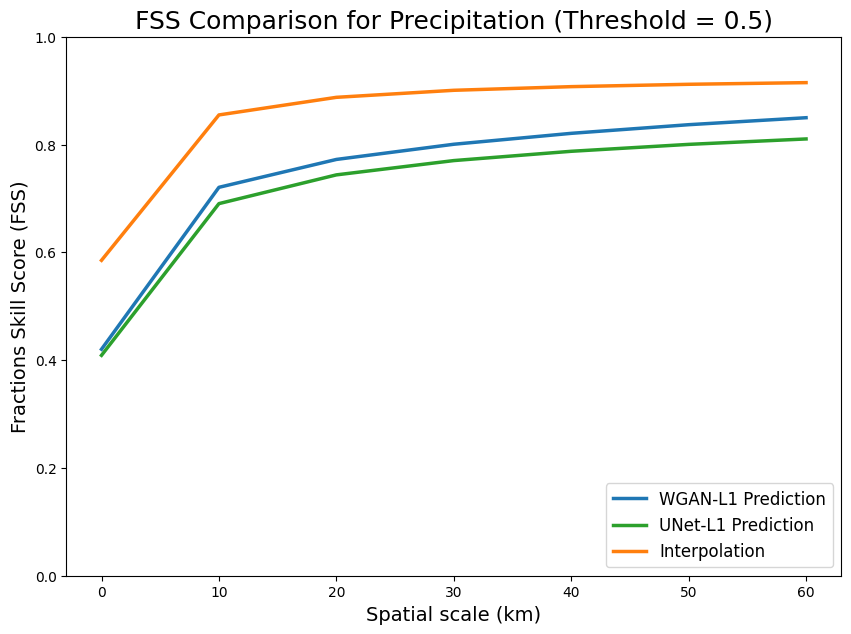

In [10]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from pysteps.verification.spatialscores import fss

# 加载 WGAN-L1 数据集
ds_wgan = xr.open_dataset("/cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/public/ShiXiSheng/yzy/yzy_results/ex31_7_onestepwgan_cri5_1000_0_l1_aheadtop_10_180epoch_addprecipnorm/prcp_downs_wgan_year_2020.nc")
fcst_wgan = ds_wgan['fcst'].values
hr_wgan = ds_wgan['hr'].values
inter = ds_wgan['inter'].values  # 插值结果，WGAN 和 UNet 相同

# 加载 UNet-L1 数据集
ds_unet = xr.open_dataset("/cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/public/ShiXiSheng/yzy/yzy_results/ex7_13_onestep_l1_nofc_aheadtop_10_addprecipnorm/prcp_downs_unet_year_2020.nc")
fcst_unet = ds_unet['fcst'].values
hr_unet = ds_unet['hr'].values

# 形状调整 (time, lat, lon -> (time, spatial))
fcst_wgan = fcst_wgan.reshape(fcst_wgan.shape[0], -1)
fcst_unet = fcst_unet.reshape(fcst_unet.shape[0], -1)
inter = inter.reshape(inter.shape[0], -1)
hr_wgan = hr_wgan.reshape(hr_wgan.shape[0], -1)
hr_unet = hr_unet.reshape(hr_unet.shape[0], -1)

# 固定阈值和尺度
threshold = 0.5
radii = [0, 10, 20, 30, 40, 50, 60]

# 计算 FSS
fss_fcst_wgan = []
fss_fcst_unet = []
fss_inter = []

for radius in radii:
    # WGAN fcst vs hr
    fss_fcst_wgan.append(fss(fcst_wgan, hr_wgan, threshold, scale=radius))
    # UNet fcst vs hr
    fss_fcst_unet.append(fss(fcst_unet, hr_unet, threshold, scale=radius))
    # Interpolation vs hr
    fss_inter.append(fss(inter, hr_wgan, threshold, scale=radius))

# 绘图
plt.figure(figsize=(10, 7))

# 绘制曲线
plt.plot(radii, fss_fcst_wgan, label='WGAN-L1 Prediction', color='tab:blue', linewidth=2.5)
plt.plot(radii, fss_fcst_unet, label='UNet-L1 Prediction', color='tab:green', linewidth=2.5)
plt.plot(radii, fss_inter, label='Interpolation', color='tab:orange', linewidth=2.5)

# 图表设置
plt.xlabel('Spatial scale (km)', fontsize=14)
plt.ylabel('Fractions Skill Score (FSS)', fontsize=14)
plt.title(f'FSS Comparison for Precipitation (Threshold = {threshold})', fontsize=18)
plt.ylim(0, 1.0)  # 限制Y轴范围

# 去掉网格线
plt.grid(False)

# 调整图例位置
plt.legend(loc='lower right', fontsize=12)

plt.show()


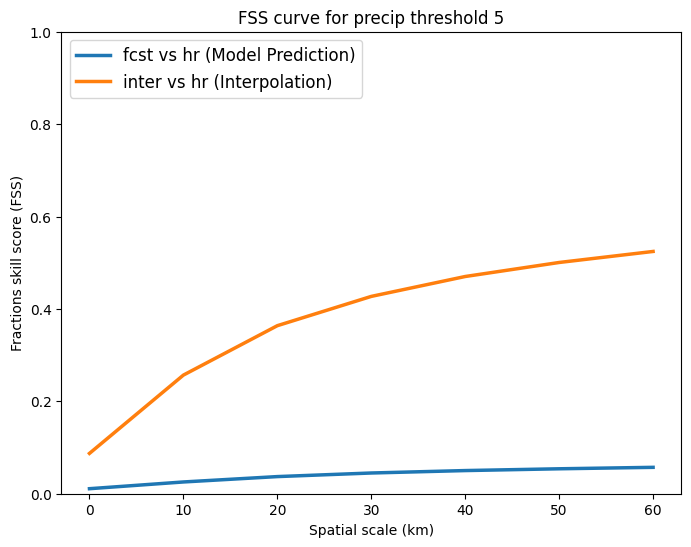

In [40]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from pysteps.verification.spatialscores import fss

# 加载数据集
ds = xr.open_dataset("/cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/public/ShiXiSheng/yzy/yzy_results/ex7_13_onestep_l1_nofc_aheadtop_10_addprecipnorm/prcp_downs_unet_year_2020.nc")

fcst = ds['fcst'].values  # 模型预测
inter = ds['inter'].values  # 插值结果
hr = ds['hr'].values  # 观测数据

# 形状调整
fcst = fcst.reshape(fcst.shape[0], -1)
inter = inter.reshape(inter.shape[0], -1)
hr = hr.reshape(hr.shape[0], -1)

# 固定阈值和尺度
threshold = 5
radii = [0, 10, 20, 30, 40, 50, 60]

# 计算FSS
fss_fcst = []
fss_inter = []

for radius in radii:
    # fcst vs hr
    fss_fcst.append(fss(fcst, hr, threshold, scale=radius))
    # inter vs hr
    fss_inter.append(fss(inter, hr, threshold, scale=radius))

# 绘图
plt.figure(figsize=(8, 6))

# 绘制加粗曲线
plt.plot(radii, fss_fcst, label='fcst vs hr (Model Prediction)', color='tab:blue', linewidth=2.5)
plt.plot(radii, fss_inter, label='inter vs hr (Interpolation)', color='tab:orange', linewidth=2.5)

plt.xlabel('Spatial scale (km)')
plt.ylabel('Fractions skill score (FSS)')
plt.title(f'FSS curve for precip threshold {threshold}')
plt.ylim(0, 1.0)  # 限制Y轴范围

# 去掉网格线
plt.grid(False)  

# 将图例移至右下角
plt.legend(loc='upper left', fontsize=12)

plt.show()


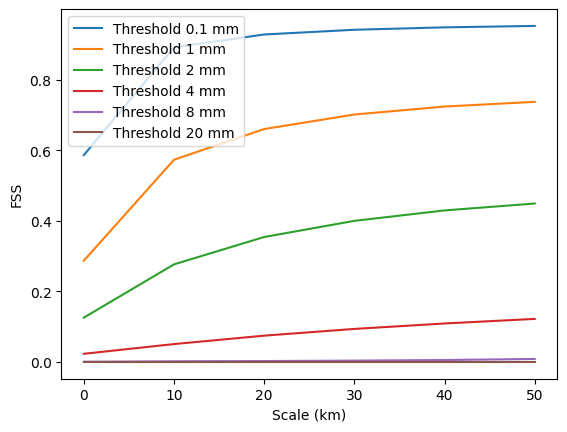

In [2]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from pysteps.verification.spatialscores import fss

# 加载数据集
ds = xr.open_dataset("/cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/public/ShiXiSheng/yzy/yzy_results/ex7_2_onestep_l1_nofc_aheadtop_5/prcp_downs_unet_year_2020.nc")

# 提取数据
y_pred_np = ds['fcst'].values
tar_np = ds['hr'].values

tar_np = tar_np.reshape(tar_np.shape[1],-1)
y_pred_np = y_pred_np.reshape(y_pred_np.shape[1],-1)

# 定义阈值和scales
thresholds = [0.1, 1, 2, 4, 8, 20]
radii = [0, 10, 20, 30, 40, 50]

# 计算FSS
fss_scores = {thresh: [] for thresh in thresholds}
for radius in radii:
    for thresh in thresholds:
        fss_value = fss(y_pred_np, tar_np, thresh, scale=radius)
        fss_scores[thresh].append(fss_value)

# 绘图
fig, ax = plt.subplots()
for thresh in thresholds:
    ax.plot(radii, fss_scores[thresh], label=f'Threshold {thresh} mm')
ax.set_xlabel('Scale (km)')
ax.set_ylabel('FSS')
ax.legend()
plt.show()

Pysteps configuration file found at: /cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/yinzunyi/py3.9/lib/python3.9/site-packages/pysteps/pystepsrc



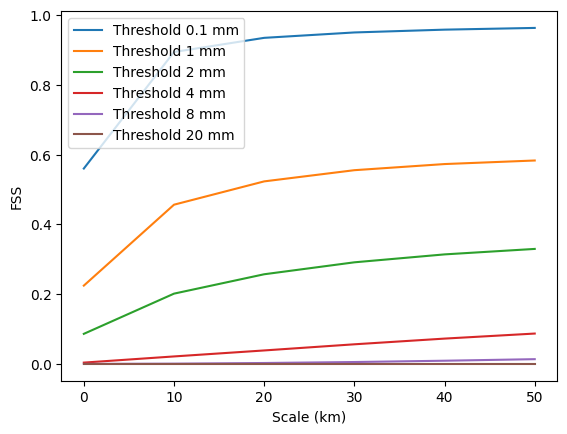

In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from pysteps.verification.spatialscores import fss

# 加载数据集
ds = xr.open_dataset("/cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/public/ShiXiSheng/yzy/yzy_results/ex7_3_onestep_l1_nofc_aheadtop_50/prcp_downs_unet_year_2020.nc")

# 提取数据
y_pred_np = ds['fcst'].values
tar_np = ds['hr'].values

tar_np = tar_np.reshape(tar_np.shape[1],-1)
y_pred_np = y_pred_np.reshape(y_pred_np.shape[1],-1)

# 定义阈值和scales
thresholds = [0.1, 1, 2, 4, 8, 20]
radii = [0, 10, 20, 30, 40, 50]

# 计算FSS
fss_scores = {thresh: [] for thresh in thresholds}
for radius in radii:
    for thresh in thresholds:
        fss_value = fss(y_pred_np, tar_np, thresh, scale=radius)
        fss_scores[thresh].append(fss_value)

# 绘图
fig, ax = plt.subplots()
for thresh in thresholds:
    ax.plot(radii, fss_scores[thresh], label=f'Threshold {thresh} mm')
ax.set_xlabel('Scale (km)')
ax.set_ylabel('FSS')
ax.legend()
plt.show()

Pysteps configuration file found at: /cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/yinzunyi/py3.9/lib/python3.9/site-packages/pysteps/pystepsrc



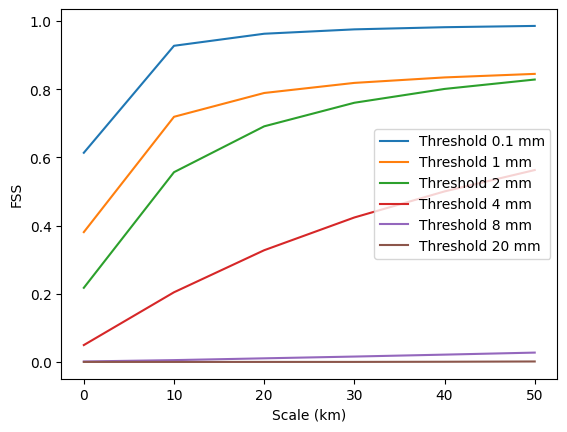

In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from pysteps.verification.spatialscores import fss

# 加载数据集
ds = xr.open_dataset("/cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/public/ShiXiSheng/yzy/yzy_results/ex17_onestepwgan_weightmae_aheadtop_0.008/prcp_downs_wgan_year_2020.nc")

# 提取数据
y_pred_np = ds['fcst'].values
tar_np = ds['hr'].values

tar_np = tar_np.reshape(tar_np.shape[1],-1)
y_pred_np = y_pred_np.reshape(y_pred_np.shape[1],-1)

# 定义阈值和scales
thresholds = [0.1, 1, 2, 4, 8, 20]
radii = [0, 10, 20, 30, 40, 50]

# 计算FSS
fss_scores = {thresh: [] for thresh in thresholds}
for radius in radii:
    for thresh in thresholds:
        fss_value = fss(y_pred_np, tar_np, thresh, scale=radius)
        fss_scores[thresh].append(fss_value)

# 绘图
fig, ax = plt.subplots()
for thresh in thresholds:
    ax.plot(radii, fss_scores[thresh], label=f'Threshold {thresh} mm')
ax.set_xlabel('Scale (km)')
ax.set_ylabel('FSS')
ax.legend()
plt.show()

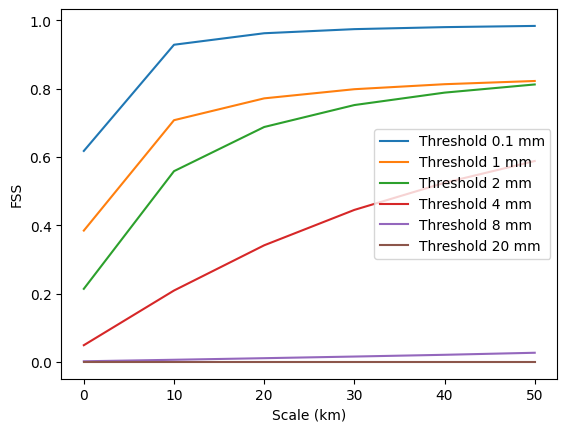

In [3]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from pysteps.verification.spatialscores import fss

# 加载数据集
ds = xr.open_dataset("/cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/public/ShiXiSheng/yzy/yzy_results/ex31_onestepwgan_cri5_181_025_weightmae_aheadtop_0.008_130epoch/prcp_downs_wgan_year_2020.nc")

# 提取数据
y_pred_np = ds['fcst'].values
tar_np = ds['hr'].values

tar_np = tar_np.reshape(tar_np.shape[1],-1)
y_pred_np = y_pred_np.reshape(y_pred_np.shape[1],-1)

# 定义阈值和scales
thresholds = [0.1, 1, 2, 4, 8, 20]
radii = [0, 10, 20, 30, 40, 50]

# 计算FSS
fss_scores = {thresh: [] for thresh in thresholds}
for radius in radii:
    for thresh in thresholds:
        fss_value = fss(y_pred_np, tar_np, thresh, scale=radius)
        fss_scores[thresh].append(fss_value)

# 绘图
fig, ax = plt.subplots()
for thresh in thresholds:
    ax.plot(radii, fss_scores[thresh], label=f'Threshold {thresh} mm')
ax.set_xlabel('Scale (km)')
ax.set_ylabel('FSS')
ax.legend()
plt.show()

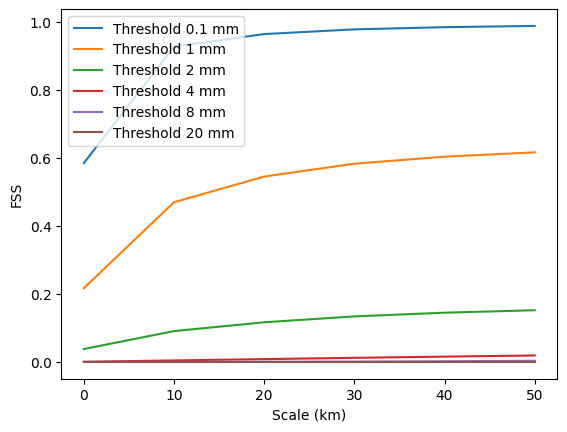

In [7]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from pysteps.verification.spatialscores import fss

# 加载数据集
ds = xr.open_dataset("/cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/public/ShiXiSheng/yzy/yzy_results/ex31_4_onestepwgan_cri5_181_025_l1_aheadtop_40_180epoch/prcp_downs_wgan_year_2020.nc")

# 提取数据
y_pred_np = ds['fcst'].values
tar_np = ds['hr'].values

tar_np = tar_np.reshape(tar_np.shape[1],-1)
y_pred_np = y_pred_np.reshape(y_pred_np.shape[1],-1)

# 定义阈值和scales
thresholds = [0.1, 1, 2, 4, 8, 20]
radii = [0, 10, 20, 30, 40, 50]

# 计算FSS
fss_scores = {thresh: [] for thresh in thresholds}
for radius in radii:
    for thresh in thresholds:
        fss_value = fss(y_pred_np, tar_np, thresh, scale=radius)
        fss_scores[thresh].append(fss_value)

# 绘图
fig, ax = plt.subplots()
for thresh in thresholds:
    ax.plot(radii, fss_scores[thresh], label=f'Threshold {thresh} mm')
ax.set_xlabel('Scale (km)')
ax.set_ylabel('FSS')
ax.legend()
plt.show()#######为什么这么多一样的呀

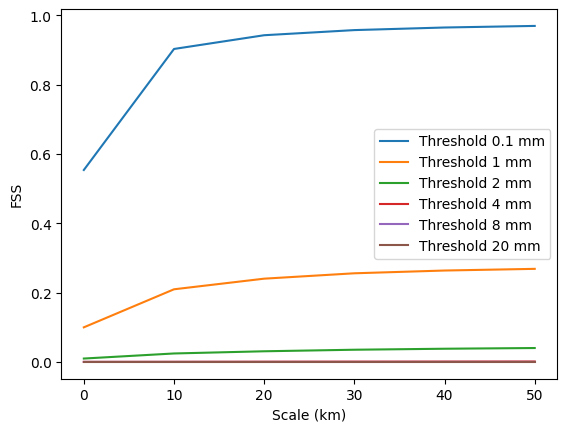

In [4]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from pysteps.verification.spatialscores import fss

# 加载数据集
ds = xr.open_dataset("/cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/public/ShiXiSheng/yzy/yzy_results/ex31_5_onestepwgan_cri5_1500_025_l1_aheadtop_10_180epoch/prcp_downs_wgan_year_2020.nc")

# 提取数据
y_pred_np = ds['fcst'].values
tar_np = ds['hr'].values

tar_np = tar_np.reshape(tar_np.shape[1],-1)
y_pred_np = y_pred_np.reshape(y_pred_np.shape[1],-1)

# 定义阈值和scales
thresholds = [0.1, 1, 2, 4, 8, 20]
radii = [0, 10, 20, 30, 40, 50]

# 计算FSS
fss_scores = {thresh: [] for thresh in thresholds}
for radius in radii:
    for thresh in thresholds:
        fss_value = fss(y_pred_np, tar_np, thresh, scale=radius)
        fss_scores[thresh].append(fss_value)

# 绘图
fig, ax = plt.subplots()
for thresh in thresholds:
    ax.plot(radii, fss_scores[thresh], label=f'Threshold {thresh} mm')
ax.set_xlabel('Scale (km)')
ax.set_ylabel('FSS')
ax.legend()
plt.show()

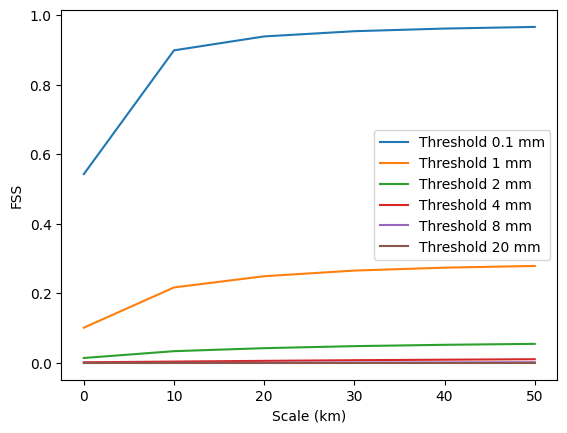

In [5]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from pysteps.verification.spatialscores import fss

# 加载数据集
ds = xr.open_dataset("/cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/public/ShiXiSheng/yzy/yzy_results/ex31_3_onestepwgan_cri5_181_025_l1_aheadtop_10_180epoch/prcp_downs_wgan_year_2020.nc")

# 提取数据
y_pred_np = ds['fcst'].values
tar_np = ds['hr'].values

tar_np = tar_np.reshape(tar_np.shape[1],-1)
y_pred_np = y_pred_np.reshape(y_pred_np.shape[1],-1)

# 定义阈值和scales
thresholds = [0.1, 1, 2, 4, 8, 20]
radii = [0, 10, 20, 30, 40, 50]

# 计算FSS
fss_scores = {thresh: [] for thresh in thresholds}
for radius in radii:
    for thresh in thresholds:
        fss_value = fss(y_pred_np, tar_np, thresh, scale=radius)
        fss_scores[thresh].append(fss_value)

# 绘图
fig, ax = plt.subplots()
for thresh in thresholds:
    ax.plot(radii, fss_scores[thresh], label=f'Threshold {thresh} mm')
ax.set_xlabel('Scale (km)')
ax.set_ylabel('FSS')
ax.legend()
plt.show()

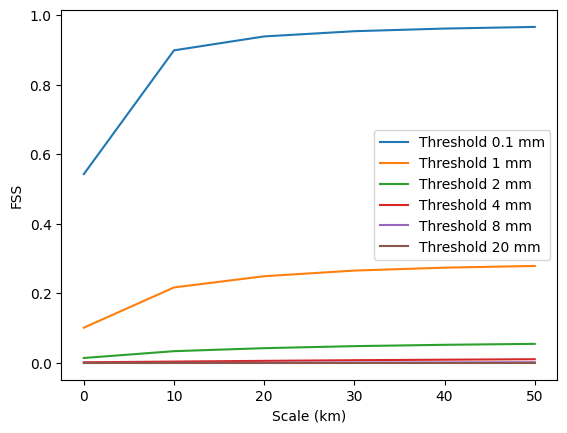

In [6]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from pysteps.verification.spatialscores import fss

# 加载数据集
ds = xr.open_dataset("/cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/public/ShiXiSheng/yzy/yzy_results/ex31_3_onestepwgan_cri5_181_025_l1_aheadtop_10_180epoch/prcp_downs_wgan_year_2020.nc")

# 提取数据
y_pred_np = ds['fcst'].values
tar_np = ds['hr'].values

tar_np = tar_np.reshape(tar_np.shape[1],-1)
y_pred_np = y_pred_np.reshape(y_pred_np.shape[1],-1)

# 定义阈值和scales
thresholds = [0.1, 1, 2, 4, 8, 20]
radii = [0, 10, 20, 30, 40, 50]

# 计算FSS
fss_scores = {thresh: [] for thresh in thresholds}
for radius in radii:
    for thresh in thresholds:
        fss_value = fss(y_pred_np, tar_np, thresh, scale=radius)
        fss_scores[thresh].append(fss_value)

# 绘图
fig, ax = plt.subplots()
for thresh in thresholds:
    ax.plot(radii, fss_scores[thresh], label=f'Threshold {thresh} mm')
ax.set_xlabel('Scale (km)')
ax.set_ylabel('FSS')
ax.legend()
plt.show()

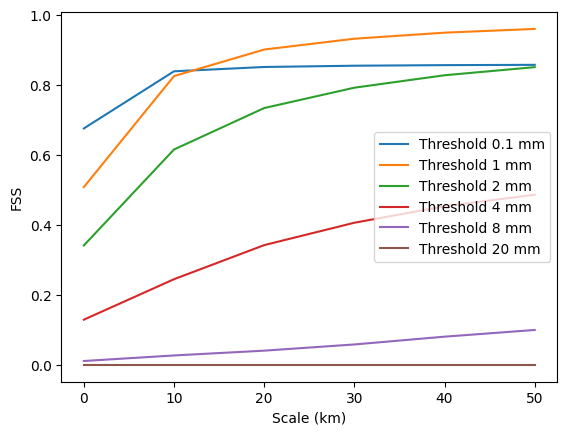

In [4]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from pysteps.verification.spatialscores import fss

# 加载数据集
ds = xr.open_dataset("/cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/public/ShiXiSheng/yzy/yzy_results/ex14_onestep_weightmae_aheadtop_0.008/prcp_downs_unet_year_2020.nc")

# 提取数据
y_pred_np = ds['fcst'].values
tar_np = ds['hr'].values

tar_np = tar_np.reshape(tar_np.shape[1],-1)
y_pred_np = y_pred_np.reshape(y_pred_np.shape[1],-1)

# 定义阈值和scales
thresholds = [0.1, 1, 2, 4, 8, 20]
radii = [0, 10, 20, 30, 40, 50]

# 计算FSS
fss_scores = {thresh: [] for thresh in thresholds}
for radius in radii:
    for thresh in thresholds:
        fss_value = fss(y_pred_np, tar_np, thresh, scale=radius)
        fss_scores[thresh].append(fss_value)

# 绘图
fig, ax = plt.subplots()
for thresh in thresholds:
    ax.plot(radii, fss_scores[thresh], label=f'Threshold {thresh} mm')
ax.set_xlabel('Scale (km)')
ax.set_ylabel('FSS')
ax.legend()
plt.show()

Pysteps configuration file found at: /cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/yinzunyi/py3.9/lib/python3.9/site-packages/pysteps/pystepsrc



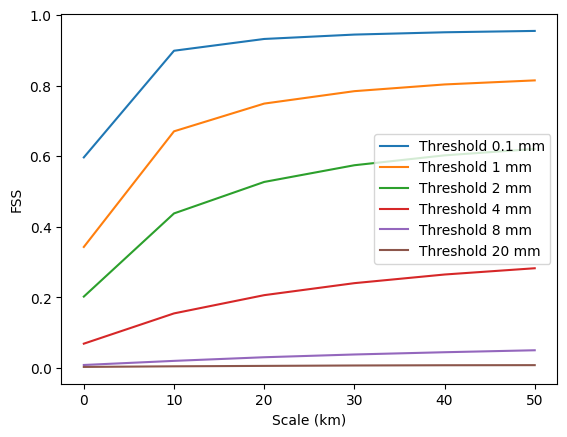

In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from pysteps.verification.spatialscores import fss

# 加载数据集
ds = xr.open_dataset("/cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/public/ShiXiSheng/yzy/yzy_results/ex7_5_onestep_l1_nofc_aheadtop_5_addprecipnorm/prcp_downs_unet_year_2020.nc")

# 提取数据
y_pred_np = ds['fcst'].values
tar_np = ds['hr'].values

tar_np = tar_np.reshape(tar_np.shape[1],-1)
y_pred_np = y_pred_np.reshape(y_pred_np.shape[1],-1)

# 定义阈值和scales
thresholds = [0.1, 1, 2, 4, 8, 20]
radii = [0, 10, 20, 30, 40, 50]

# 计算FSS
fss_scores = {thresh: [] for thresh in thresholds}
for radius in radii:
    for thresh in thresholds:
        fss_value = fss(y_pred_np, tar_np, thresh, scale=radius)
        fss_scores[thresh].append(fss_value)

# 绘图
fig, ax = plt.subplots()
for thresh in thresholds:
    ax.plot(radii, fss_scores[thresh], label=f'Threshold {thresh} mm')
ax.set_xlabel('Scale (km)')
ax.set_ylabel('FSS')
ax.legend()
plt.show()

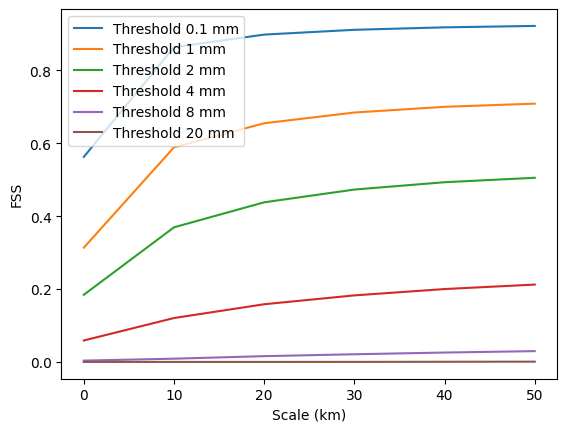

In [3]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from pysteps.verification.spatialscores import fss

# 加载数据集
ds = xr.open_dataset("/cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/public/ShiXiSheng/yzy/yzy_results/ex7_6_onestep_l1_nofc_aheadtop_10_addprecipnorm/prcp_downs_unet_year_2020.nc")

# 提取数据
y_pred_np = ds['fcst'].values
tar_np = ds['hr'].values

tar_np = tar_np.reshape(tar_np.shape[1],-1)
y_pred_np = y_pred_np.reshape(y_pred_np.shape[1],-1)

# 定义阈值和scales
thresholds = [0.1, 1, 2, 4, 8, 20]
radii = [0, 10, 20, 30, 40, 50]

# 计算FSS
fss_scores = {thresh: [] for thresh in thresholds}
for radius in radii:
    for thresh in thresholds:
        fss_value = fss(y_pred_np, tar_np, thresh, scale=radius)
        fss_scores[thresh].append(fss_value)

# 绘图
fig, ax = plt.subplots()
for thresh in thresholds:
    ax.plot(radii, fss_scores[thresh], label=f'Threshold {thresh} mm')
ax.set_xlabel('Scale (km)')
ax.set_ylabel('FSS')
ax.legend()
plt.show()

Pysteps configuration file found at: /cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/yinzunyi/py3.9/lib/python3.9/site-packages/pysteps/pystepsrc



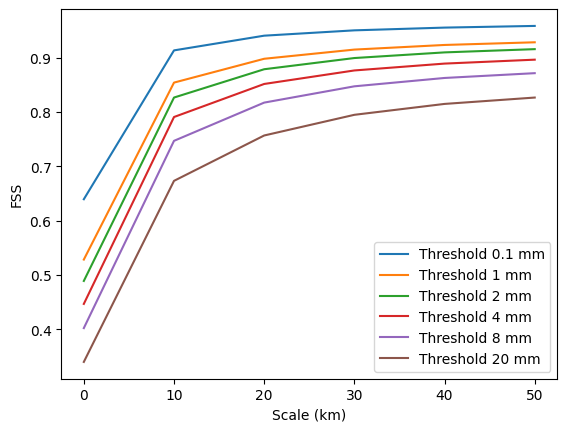

In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from pysteps.verification.spatialscores import fss

# 加载数据集
ds = xr.open_dataset("/cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/public/ShiXiSheng/yzy/yzy_results/ex7_7_onestep_l1_nofc_aheadtop_05_addprecipnorm/prcp_downs_unet_year_2020.nc")

# 提取数据
y_pred_np = ds['fcst'].values
tar_np = ds['hr'].values

tar_np = tar_np.reshape(tar_np.shape[1],-1)
y_pred_np = y_pred_np.reshape(y_pred_np.shape[1],-1)

# 定义阈值和scales
thresholds = [0.1, 1, 2, 4, 8, 20]
radii = [0, 10, 20, 30, 40, 50]

# 计算FSS
fss_scores = {thresh: [] for thresh in thresholds}
for radius in radii:
    for thresh in thresholds:
        fss_value = fss(y_pred_np, tar_np, thresh, scale=radius)
        fss_scores[thresh].append(fss_value)

# 绘图
fig, ax = plt.subplots()
for thresh in thresholds:
    ax.plot(radii, fss_scores[thresh], label=f'Threshold {thresh} mm')
ax.set_xlabel('Scale (km)')
ax.set_ylabel('FSS')
ax.legend()
plt.show()